In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report

import pandas as pnd


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<h1 style="color: red;">Section 1: Data</h1>

<h2>1) Préparation de données</h2>

In [4]:
dataset =pnd.read_csv('/content/drive/MyDrive/MachineLearning/diabetes.csv')#import
X = np.array(dataset.drop(columns=['Outcome'])) #features
y = np.array(dataset['Outcome']) #target
#spilt data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23)


**Importance du decoupage en training et testing set**

Le training set sert à entraîner les paramètres du modèle. Le test set sert à évaluer sa capacité de généralisation sur des données jamais vues auparavant. Cette séparation permet d’éviter le problème d’overfitting (surapprentissage) et la surestimation des performances du modèle.

In [ ]:
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<h1 style="color: red;">Section 2: Neural network avec tensorflow</h1>

**Architecture choisie**

   * Inputs du reseau : `8` variables explicatives.
   * Couche de sortie : `1` neurone, car Outcome est binaire.
   * Activation de sortie : sigmoid, pour produire une probabilite entre `0` et `1`.


In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.optimizers import Adam

<h2>2) Modèle de réseau de neurones</h2>

In [8]:
model_nn = Sequential()
output_layer=Dense(1, input_shape=(X_train.shape[1],), activation='sigmoid')
model_nn.add(output_layer)
opt = Adam(learning_rate=0.001)
model_nn.compile(optimizer=opt,loss="binary_crossentropy",metrics=["accuracy","precision"])
model_nn.fit(X_train, y_train, epochs = 1000, verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model_nn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20 (84.00 B)

**Role de `fit`**

La fonction `fit` est utilisée pour entraîner notre modèle. Pour chaque epoch, elle calcule les prédictions, l'erreur, puis met à jour les poids et le biais pour minimiser l’erreur.

=========================================================================

**Nombre des paramètre**

Notre modèle contient 9 paramètres
* 8 paramètre représentant les 8 poids.
* 1 paramètre représentant le bias `b`.

=========================================================================

**Pourquoi faire du tuning ?**

Il est important de faire du tuning (réglage des hyperparamètres) lorsqu’un modèle n’apprend pas correctement ou ne généralise pas bien.

Le tuning consiste à ajuster des éléments comme :
* learning rate,
* nombre d’epochs,
* batch size,
* nombre de neurones/couches,
* régularisation,
* type de fonction d’activation

<h2>3) Prédiction en utilisant le modèle</h2>

In [10]:
yhat_nn=model_nn.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [11]:
yhat_nn=yhat_nn.flatten()

In [12]:
W_nn, bias_nn = model_nn.layers[0].get_weights()

# Afficher les poids et biais
print("Poids :", W_nn.flatten())
print("Biais :", bias_nn)

Poids : [ 0.07328866  0.02438978 -0.02075242  0.00096384 -0.0007247   0.04232923
  0.6201921   0.00427849]
Biais : [-4.2887483]


In [13]:
yhat_manual_proba = (1 / (1 + np.exp(-(X_test @ W_nn + bias_nn)))).flatten()
print("Predictions manuelles :", yhat_manual_proba[:5])
print("Predictions proches de predict :", np.allclose(yhat_nn, yhat_manual_proba, atol=1e-6))



Predictions manuelles : [0.31311446 0.87926448 0.62956583 0.37238732 0.16591576]
Predictions proches de predict : True


<h2>4) Evaluation du modèle</h2>

Train MSE: 0.1568787842988968 | Train R2: -2.733333110809326
Test MSE: 0.1568787842988968 | Test R2: -2.733333110809326


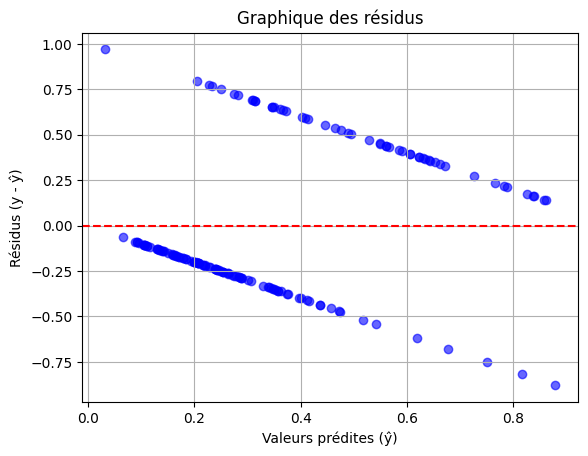

In [15]:
#code à fournir
from sklearn.metrics import mean_squared_error,r2_score

yhat_train_nn = model_nn.predict(X_train, verbose=0).flatten()

mse_nn_train,r2_nn_train=mean_squared_error(y_train,yhat_train_nn),r2_score(y_train,yhat_train_nn)
mse_nn_test,r2_nn_test=mean_squared_error(yhat_nn,y_test),r2_score(yhat_nn,y_test)

print("Train MSE:", mse_nn_test, "| Train R2:", r2_nn_test)
print("Test MSE:", mse_nn_test, "| Test R2:", r2_nn_test)

import matplotlib.pyplot as plt

# Tracé des résidus
plt.scatter(yhat_nn, y_test - yhat_nn, color='blue', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites (ŷ)")
plt.ylabel("Résidus (y - ŷ)")
plt.title("Graphique des résidus")
plt.grid(True)
plt.show()



<h1>From scratch</h1>


<h2>Modèle de régression logistic from scratch avec utilisation des matrices</h2>


In [19]:
learning_rate = 0.0001
epochs = 1000

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialisation des paramètres
W = np.zeros((X_train.shape[1], 1))  # Shape: (2, 1)
b = 0.0

# Reshape y_train pour garantir les dimensions adéquates
y_train = y_train.reshape(-1, 1)  # Shape: (n_samples, 1)
n = len(X_train)

# Entraînement (descente de gradient vectorisée)
for epoch in range(epochs):
    y_pred = sigmoid(X_train @ W + b)  # Shape: (n, 1)
    error = y_pred - y_train  # Shape: (n, 1)

    # Calcul des gradients
    dW = (1/n) * (np.dot(X_train.T, error))  # Shape: (2, 1)
    db = (1/n) * np.sum(error)        # Scalaire

    # Mise à jour des paramètres
    W -= learning_rate * dW

    b -= learning_rate * db

# Résultats
print("Paramètres ajustés:")
print(f"W = \n{W}")
print(f"b = {b:.4f}")

Paramètres ajustés:
W = 
[[ 0.01286553]
 [ 0.0142827 ]
 [-0.03123407]
 [ 0.00161999]
 [ 0.00034173]
 [-0.0040858 ]
 [ 0.00070535]
 [-0.00101959]]
b = -0.0039


In [20]:
yhat_scratch_proba = sigmoid(X_test @ W + b).flatten()
yhat_scratch_labels = (yhat_scratch_proba >= 0.5).astype(int)

print("Scratch accuracy:", accuracy_score(y_test, yhat_scratch_labels))
print("Scratch recall  :", recall_score(y_test, yhat_scratch_labels))
print("Scratch f1-score:", f1_score(y_test, yhat_scratch_labels))
print(confusion_matrix(y_test, yhat_scratch_labels))



Scratch accuracy: 0.6688311688311688
Scratch recall  : 0.22641509433962265
Scratch f1-score: 0.32
[[91 10]
 [41 12]]
